### Yoonjae Lee

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.transform import rotate

img = io.imread("Images/Group_6.png")
rows, cols = 6, 9
h, w = img.shape[0], img.shape[1]
cell_h = h // rows
cell_w = w // cols


In [2]:
# Slice one letter from the grid using row r, column c (Lab 4.1: img[y1:y2, x1:x2])
def get_letter(r, c, margin=6):
    y1 = r * cell_h + margin
    y2 = min((r + 1) * cell_h, h) - margin
    x1 = c * cell_w + margin
    x2 = min((c + 1) * cell_w, w) - margin
    return img[y1:y2, x1:x2]


In [3]:
# Crop each patch to the same height and width (take the smallest size, cut from the middle)
def crop_to_size(patch, out_h, out_w):
    ph, pw = patch.shape[0], patch.shape[1]
    y0 = max(0, (ph - out_h) // 2)
    x0 = max(0, (pw - out_w) // 2)
    return patch[y0 : y0 + out_h, x0 : x0 + out_w]


In [4]:
FIRST = [(0, 7), (1, 1), (1, 1), (0, 2), (3, 8), (1, 2), (5, 2)]
LAST = [(5, 1), (5, 2), (5, 2)]
MARGIN = 6

# Rotation fixes for visibly tilted letters in Group_6
ROT = {
    (0, 7): -35,  # Y
    (1, 2): -30,  # a
    (5, 1): -30,  # L
}

def rotate_letter(patch, angle=0):
    if angle == 0:
        return patch
    r = rotate(patch, angle, resize=False, mode="constant", cval=1.0)
    return (np.clip(r, 0, 1) * 255).astype(np.uint8)

def get_processed(r, c):
    p = get_letter(r, c, MARGIN)
    p = rotate_letter(p, ROT.get((r, c), 0))
    return p

used = set(FIRST + LAST)
patches = [get_processed(r, c) for r, c in used]
out_h = min(p.shape[0] for p in patches)
out_w = min(p.shape[1] for p in patches)

first_letters = [crop_to_size(get_processed(r, c), out_h, out_w) for r, c in FIRST]
last_letters = [crop_to_size(get_processed(r, c), out_h, out_w) for r, c in LAST]


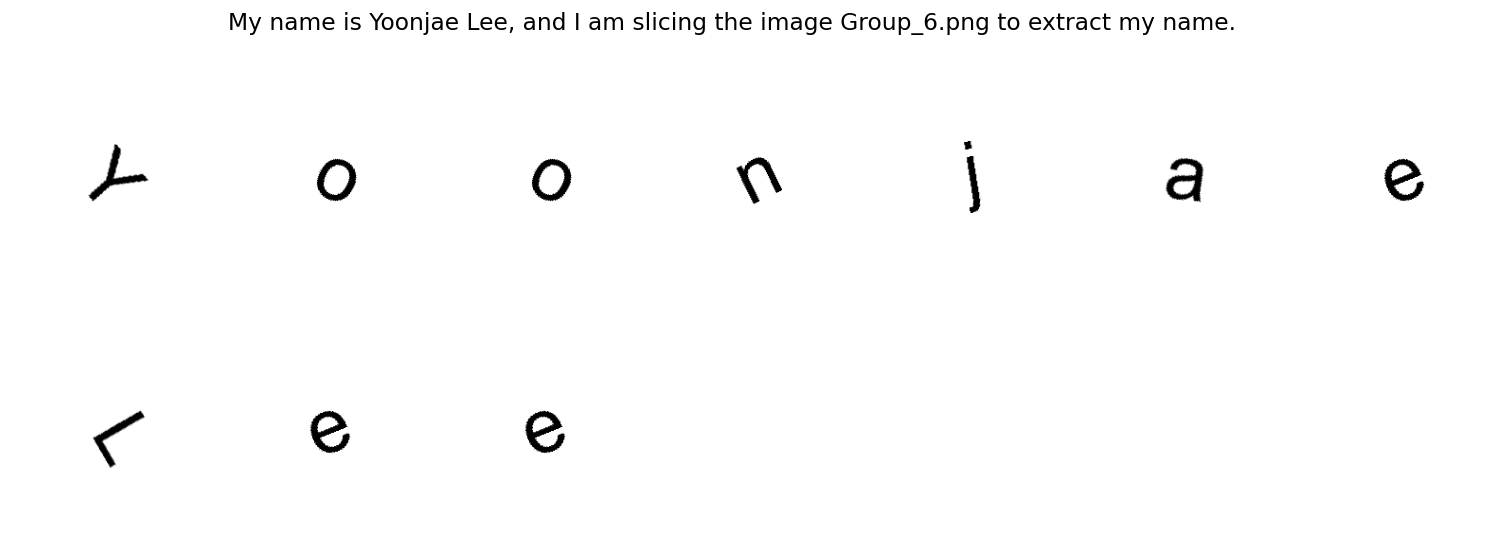

In [5]:
# One figure: first name row, then last name row
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(2, 7, height_ratios=[1, 1], hspace=0.45, top=0.88, bottom=0.08)

fig.suptitle(
    "My name is Yoonjae Lee, and I am slicing the image Group_6.png to extract my name.",
    fontsize=14,
)

for i, patch in enumerate(first_letters):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(np.clip(patch, 0, 255).astype(np.uint8))
    ax.axis("off")

for i, patch in enumerate(last_letters):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(np.clip(patch, 0, 255).astype(np.uint8))
    ax.axis("off")

for j in range(len(last_letters), 7):
    ax = fig.add_subplot(gs[1, j])
    ax.axis("off")


plt.subplots_adjust(wspace=0.08)
plt.show()
